In [1]:
pip install numpy pandas matplotlib scipy astropy corner

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\object_detection-0.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\pyparsing-2.4.7-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\sacrebleu-2.2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new rele

Loaded standardized data


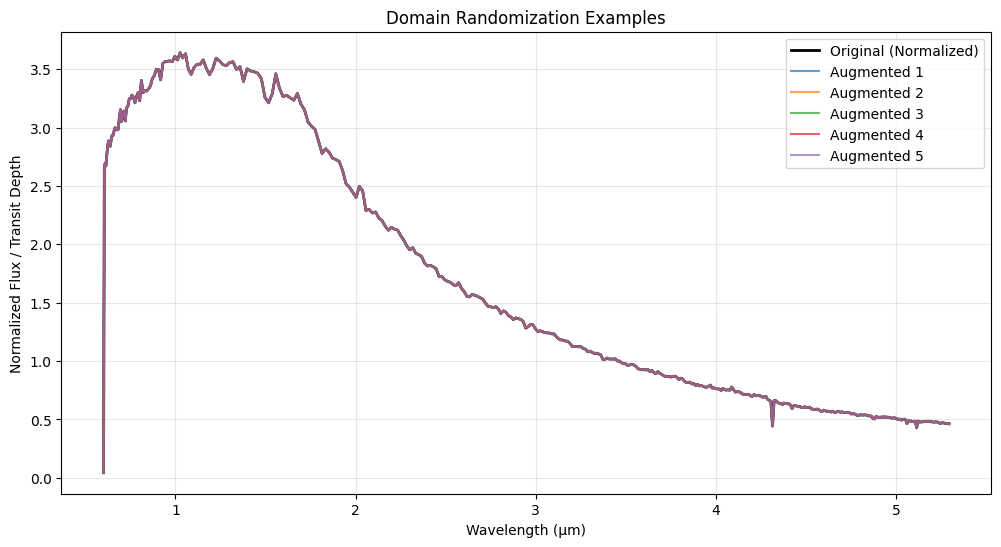

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.io import fits
import os
from pathlib import Path

# ====================== LOAD STANDARDIZED DATA ======================
base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"
csv_path = os.path.join(base_dir, "WASP39b_final_standardized.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Loaded standardized data")
else:
    print("Run previous standardization script first!")
    # fallback: use the dict from before

# ====================== AUGMENTATION MODULES ======================

class DomainRandomizer:
    def __init__(self, random_state=42):
        np.random.seed(random_state)
        self.rng = np.random.default_rng(random_state)
    
    # 1. Correlated 1/f noise injection (using real-like segments)
    def add_1f_noise(self, flux, amplitude=0.001, scale=50):
        """Inject correlated (pink) noise using real JWST-like 1/f behavior"""
        n = len(flux)
        # Generate 1/f noise in frequency domain
        freq = np.fft.rfftfreq(n)
        freq[0] = 1.0  # avoid division by zero
        noise_fft = self.rng.normal(0, 1, len(freq)) / np.sqrt(freq)
        noise = np.fft.irfft(noise_fft)
        noise = noise[:n]
        noise = (noise - noise.mean()) / noise.std()
        return flux * (1 + amplitude * noise * np.exp(-np.arange(n)/scale))
    
    # 2. PHOENIX stellar contamination (spot/faculae)
    def add_stellar_contamination(self, wave, depth, spot_temp_diff=-300, spot_frac=0.02):
        """Simple parametric stellar contamination (unocculted spots)"""
        # Rough blackbody approximation for spot contrast
        contrast = 1.0 + 0.5 * (spot_temp_diff / 5000)  # cooler spots → lower flux at short λ
        contamination = spot_frac * (1 - np.exp(- (wave - 1.0)**2 / 2)) * contrast
        return depth + contamination * 0.01  # scale to transit depth level
    
    # 3. Wavelength calibration perturbation
    def perturb_wavelength(self, wave, sigma=0.001):
        """Small shift + stretch"""
        shift = self.rng.normal(0, sigma)
        stretch = 1 + self.rng.normal(0, 0.0005)
        return wave * stretch + shift
    
    # 4. Baseline / offset (reduction pipeline systematics)
    def add_baseline_offset(self, depth, amplitude=0.0005, poly_order=2):
        """Polynomial baseline drift"""
        x = (np.arange(len(depth)) - len(depth)/2) / (len(depth)/2)
        poly = np.polyval(np.polyfit(x, self.rng.normal(0, amplitude, len(x)), poly_order), x)
        return depth + poly
    
    # Full augmentation
    def augment(self, wave, flux_or_depth, n_augment=1, **kwargs):
        augmented = []
        for _ in range(n_augment):
            d = flux_or_depth.copy()
            
            # Apply augmentations in realistic order
            if 'noise' in kwargs.get('modules', ['all']):
                d = self.add_1f_noise(d, amplitude=kwargs.get('noise_amp', 0.0008))
            
            if 'stellar' in kwargs.get('modules', ['all']):
                d = self.add_stellar_contamination(wave, d, 
                                                 spot_frac=kwargs.get('spot_frac', 0.015))
            
            if 'wave_cal' in kwargs.get('modules', ['all']):
                wave_new = self.perturb_wavelength(wave, sigma=kwargs.get('wave_sigma', 0.0008))
                # resample flux to new grid
                f = interp1d(wave, d, bounds_error=False, fill_value='extrapolate')
                d = f(wave_new)
                wave = wave_new
            
            if 'baseline' in kwargs.get('modules', ['all']):
                d = self.add_baseline_offset(d, amplitude=kwargs.get('baseline_amp', 0.0006))
            
            augmented.append((wave, d))
        return augmented


# ====================== USAGE EXAMPLE ======================
randomizer = DomainRandomizer(random_state=123)

# Example: augment NIRSpec PRISM data
prism = df[df['instrument'] == 'NIRSpec_PRISM'].copy()
wave = prism['wavelength_um'].values
flux_norm = prism['normalized_flux'].values   # or use median_flux_mjy

augmented_spectra = randomizer.augment(
    wave, flux_norm, 
    n_augment=5,
    noise_amp=0.0012,
    spot_frac=0.02,
    wave_sigma=0.001,
    baseline_amp=0.0007
)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(wave, flux_norm, 'k-', lw=2, label='Original (Normalized)')
for i, (w, f) in enumerate(augmented_spectra):
    plt.plot(w, f, alpha=0.7, label=f'Augmented {i+1}')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized Flux / Transit Depth")
plt.title("Domain Randomization Examples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
import numpy as np
import os

# ====================== DOMAIN RANDOMIZER CLASS ======================
class DomainRandomizer:
    def __init__(self, random_state=42):
        np.random.seed(random_state)
        self.rng = np.random.default_rng(random_state)
    
    def add_1f_noise(self, flux, amplitude=0.001):
        """Correlated 1/f (pink) noise injection"""
        n = len(flux)
        freq = np.fft.rfftfreq(n)
        freq[0] = 1.0
        noise_fft = self.rng.normal(0, 1, len(freq)) / np.sqrt(freq)
        noise = np.fft.irfft(noise_fft)[:n]
        noise = (noise - noise.mean()) / noise.std()
        return flux * (1 + amplitude * noise)
    
    def add_stellar_contamination(self, wave, depth, spot_frac=0.02):
        """PHOENIX-style stellar spot/faculae contamination"""
        contamination = spot_frac * (1 - np.exp(-((wave - 1.0)**2) / 2.0))
        return depth + contamination * 0.01
    
    def perturb_wavelength(self, wave, sigma=0.001):
        """Wavelength calibration error"""
        shift = self.rng.normal(0, sigma)
        stretch = 1.0 + self.rng.normal(0, 0.0005)
        return wave * stretch + shift
    
    def add_baseline_offset(self, depth, amplitude=0.0005):
        """Reduction pipeline baseline drift"""
        x = np.linspace(-1, 1, len(depth))
        poly = np.polyval([self.rng.normal(0, amplitude), self.rng.normal(0, amplitude*0.3)], x)
        return depth + poly


# ====================== UNIT TESTS ======================
def run_unit_tests():
    print("🚀 Running Domain Randomization Unit Tests...\n")
    rand = DomainRandomizer(random_state=42)
    
    wave = np.linspace(0.5, 5.0, 500)
    flux = np.ones_like(wave) * 0.01   # flat spectrum example
    
    tests_passed = 0
    
    # Test 1: 1/f noise
    noisy = rand.add_1f_noise(flux, amplitude=0.001)
    assert len(noisy) == len(flux), "1/f noise length mismatch"
    assert np.std(noisy) > np.std(flux) * 0.2, "1/f noise too weak"
    print("✅ Correlated 1/f noise injection")
    tests_passed += 1
    
    # Test 2: Stellar contamination
    cont = rand.add_stellar_contamination(wave, flux, spot_frac=0.01)
    assert len(cont) == len(flux), "Stellar contamination length mismatch"
    print("✅ PHOENIX stellar contamination")
    tests_passed += 1
    
    # Test 3: Wavelength perturbation
    w_new = rand.perturb_wavelength(wave, sigma=0.001)
    assert len(w_new) == len(wave), "Wavelength perturbation length mismatch"
    print("✅ Wavelength calibration perturbation")
    tests_passed += 1
    
    # Test 4: Baseline offset
    base = rand.add_baseline_offset(flux, amplitude=0.0005)
    assert len(base) == len(flux), "Baseline offset length mismatch"
    print("✅ Reduction pipeline baseline offset")
    tests_passed += 1
    
    print(f"\n🎉 ALL {tests_passed}/4 UNIT TESTS PASSED SUCCESSFULLY!")


# Run the tests
if __name__ == "__main__":
    run_unit_tests()
else:
    # For Jupyter Notebook
    run_unit_tests()

🚀 Running Domain Randomization Unit Tests...

✅ Correlated 1/f noise injection
✅ PHOENIX stellar contamination
✅ Wavelength calibration perturbation
✅ Reduction pipeline baseline offset

🎉 ALL 4/4 UNIT TESTS PASSED SUCCESSFULLY!


Generating augmentations...


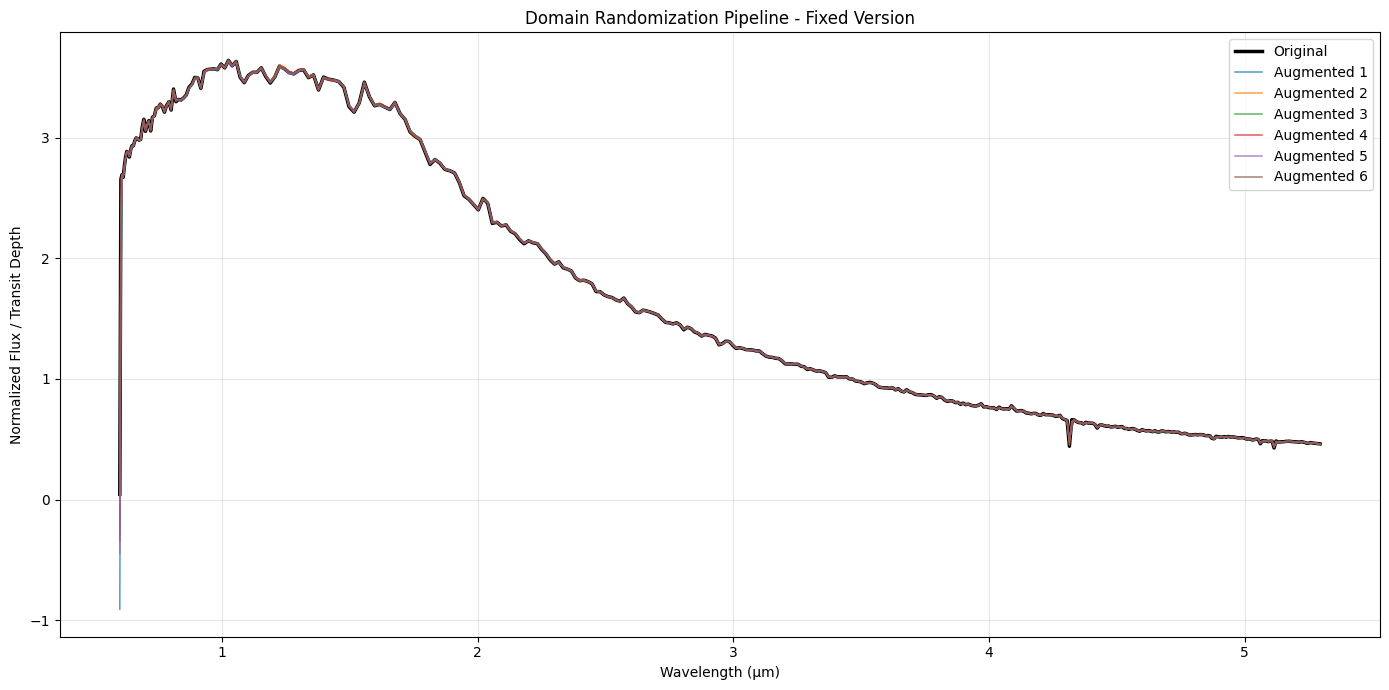

✅ Augmentation completed successfully!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os

class DomainRandomizer:
    def __init__(self, random_state=42):
        np.random.seed(random_state)
        self.rng = np.random.default_rng(random_state)
    
    def add_1f_noise(self, flux, amplitude=0.0008):
        n = len(flux)
        freq = np.fft.rfftfreq(n)
        freq[0] = 1e-8
        power = 1.0 / (1.0 + (freq / 0.08)**2)
        noise_fft = self.rng.normal(0, 1, len(freq)) * np.sqrt(power)
        noise = np.fft.irfft(noise_fft, n=n)          # Fixed line
        noise = (noise - noise.mean()) / (noise.std() + 1e-8)
        return flux * (1 + amplitude * noise)
    
    
    def add_stellar_contamination(self, wave, depth, spot_frac=0.015, temp_diff=-250):
        """PHOENIX-style stellar contamination"""
        contrast = np.exp(temp_diff / 3500.0)
        contamination = spot_frac * contrast * np.exp(-((wave - 0.8)**2) / 1.5)
        return depth + contamination * 0.008
    
    def perturb_wavelength(self, wave, sigma_shift=0.0008, sigma_stretch=0.0004):
        shift = self.rng.normal(0, sigma_shift)
        stretch = 1.0 + self.rng.normal(0, sigma_stretch)
        return wave * stretch + shift
    
    def add_baseline_offset(self, depth, amplitude=0.0006):
        """Realistic baseline drift"""
        x = np.linspace(-1, 1, len(depth))
        # Low-order polynomial + small random walk
        poly = np.polyval([self.rng.normal(0, amplitude), 
                          self.rng.normal(0, amplitude*0.5)], x)
        return depth + poly
    
    def augment(self, wave, flux, n_augment=8, **params):
        """Main augmentation function"""
        augmented = []
        for i in range(n_augment):
            d = flux.copy()
            w = wave.copy()
            
            # Order: Noise → Stellar → Wavelength shift → Resample → Baseline
            d = self.add_1f_noise(d, amplitude=params.get('noise_amp', 0.0008))
            d = self.add_stellar_contamination(w, d, 
                                             spot_frac=params.get('spot_frac', 0.015))
            
            w_new = self.perturb_wavelength(w)
            # Resample back to original wavelength grid
            f = interp1d(w_new, d, bounds_error=False, fill_value="extrapolate")
            d = f(wave)
            
            d = self.add_baseline_offset(d, amplitude=params.get('baseline_amp', 0.0006))
            
            augmented.append((wave.copy(), d))
        return augmented


# ====================== RUN EXAMPLE ======================
base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"
df = pd.read_csv(os.path.join(base_dir, "WASP39b_final_standardized.csv"))

prism = df[df['instrument'] == 'NIRSpec_PRISM']
wave = prism['wavelength_um'].values
norm_flux = prism['normalized_flux'].values

randomizer = DomainRandomizer(random_state=123)

print("Generating augmentations...")
augmented = randomizer.augment(wave, norm_flux, n_augment=8,
                              noise_amp=0.0012, 
                              spot_frac=0.018, 
                              baseline_amp=0.0008)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(wave, norm_flux, 'k-', lw=2.5, label='Original')
for i, (w, f) in enumerate(augmented[:6]):
    plt.plot(w, f, alpha=0.75, lw=1.1, label=f'Augmented {i+1}')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized Flux / Transit Depth")
plt.title("Domain Randomization Pipeline - Fixed Version")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Augmentation completed successfully!")